In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# Simulate 500 customers grouped into 4 hidden behavioral clusters
X, _ = make_blobs(n_samples=500, n_features=3, centers=4, cluster_std=1.2, random_state=42)

# Convert to DataFrame and make numbers look realistic
df = pd.DataFrame(X, columns=['Age', 'Annual_Income', 'Spending_Score'])
df['Age'] = np.abs(df['Age'] * 10 + 35).astype(int)
df['Annual_Income'] = np.abs(df['Annual_Income'] * 15 + 60).astype(int)
df['Spending_Score'] = np.abs(df['Spending_Score'] * 10 + 50).astype(int)

# Notice there is NO 'Target' column here!
df.head()

,Age,Annual_Income,Spending_Score
0,52,100,142
1,52,145,79
2,70,37,27
3,5,186,88
4,94,74,150


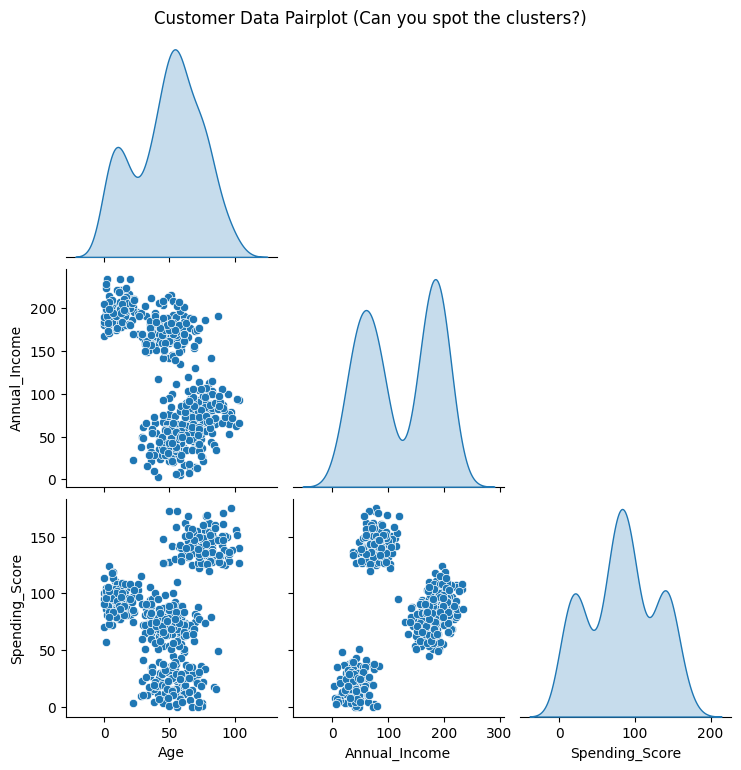

In [2]:
# A pairplot shows every feature plotted against every other feature
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle('Customer Data Pairplot ', y=1.02)
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Data scaled successfully!")

Data scaled successfully!


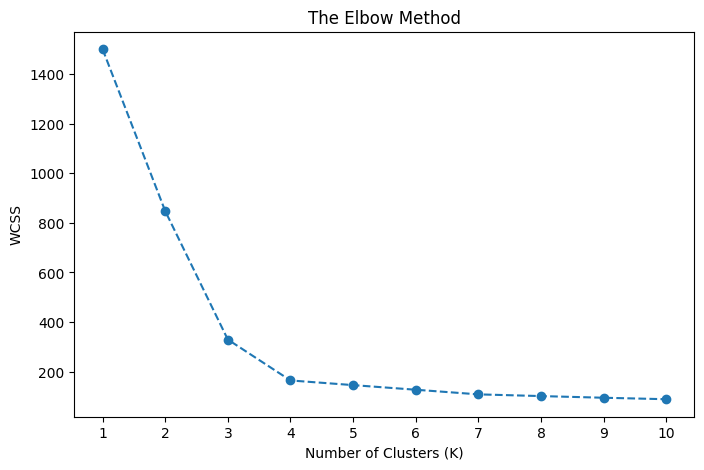

In [4]:
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Inertia is the WCSS

# Plot the Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(K_range)
plt.show()

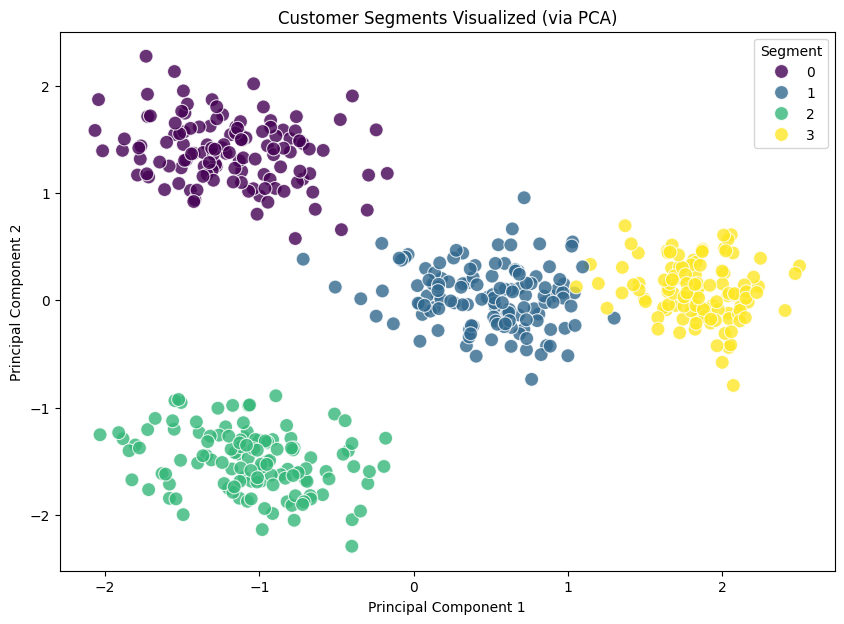

                   Age  Annual_Income  Spending_Score
Customer_Segment                                     
0                 76.3           78.9           143.0
1                 50.5          171.9            73.7
2                 53.7           42.4            20.4
3                 11.6          196.7            93.7


In [5]:
from sklearn.decomposition import PCA

# 1. Train final K-Means model
final_kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add the predicted clusters back to our original dataframe
df['Customer_Segment'] = cluster_labels

# 2. Use PCA to compress 3D data down to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Visualize the 4 customer segments
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments Visualized (via PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Segment')
plt.show()

# Print average stats for each segment
print(df.groupby('Customer_Segment').mean().round(1))